# Samsung S26 YouTube Comments - Data Preprocessing

This notebook contains data preprocessing and analysis for Samsung S26 YouTube comments.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## 2. Load Data

In [2]:
# Load the CSV file
df = pd.read_csv('../samsungs26.csv')
print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (4953, 9)


## 3. Initial Data Exploration

In [3]:
# Display first few rows
df.head()

,comment_id,author,text,time,time_parsed,likes,is_reply,parent_id,scraped_at
0,Ugyg7rH4H2QU_sfKieV4AaABAg,@mikev751,your new thing is being somewhere else and doing the reviews without the device. bad. losing the...,6 minutes ago,1.772640e+09,1,False,NaN,2026-03-04 21:33:25
1,Ugzt0nImnV5aknWz-sR4AaABAg,@LoneyMakkaroni,Sorry but only Massive L´s for Samsungs Flagship Phones. The Privacy Screen is the biggest selli...,2 hours ago,1.772633e+09,0,False,NaN,2026-03-04 21:33:25
2,UgzArTReWCyO3788Nxp4AaABAg,@Michael_11,"The Ghost case advert makes me laugh, ""guarenteed no-yollowing"" well ofcourse it won't yellow be...",3 hours ago,1.772629e+09,0,False,NaN,2026-03-04 21:33:25
3,UgyV5qqt3XB5YqJ4NNx4AaABAg,@anirudhpai3040,"3:42 sad that , it's still an 8 bit display 🥴",3 hours ago,1.772629e+09,1,False,NaN,2026-03-04 21:33:25
4,Ugyrlep7KqEmlwF1ZPx4AaABAg,@JaWznickc04,That privacy feature should be added to ALL new phones. Great feature,4 hours ago,1.772626e+09,0,False,NaN,2026-03-04 21:33:25


In [4]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4953 entries, 0 to 4952
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   comment_id   4953 non-null   object 
 1   author       4953 non-null   object 
 2   text         4953 non-null   object 
 3   time         4953 non-null   object 
 4   time_parsed  4953 non-null   float64
 5   likes        4953 non-null   int64  
 6   is_reply     4953 non-null   bool   
 7   parent_id    0 non-null      float64
 8   scraped_at   4953 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(5)
memory usage: 314.5+ KB


In [5]:
# Statistical summary
df.describe()

,time_parsed,likes,parent_id
count,4.953000e+03,4953.000000,0.0
mean,1.772158e+09,5.260650,NaN
std,8.112948e+04,182.540452,NaN
min,1.772122e+09,0.000000,NaN
25%,1.772122e+09,0.000000,NaN
50%,1.772122e+09,0.000000,NaN
75%,1.772122e+09,0.000000,NaN
max,1.772640e+09,12000.000000,NaN


In [6]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing Values:
comment_id        0
author            0
text              0
time              0
time_parsed       0
likes             0
is_reply          0
parent_id      4953
scraped_at        0
dtype: int64

Total missing values: 4953


In [7]:
# Check for duplicate comments
duplicates = df.duplicated(subset=['text']).sum()
print(f"Duplicate comments: {duplicates}")

duplicate_ids = df.duplicated(subset=['comment_id']).sum()
print(f"Duplicate comment IDs: {duplicate_ids}")

Duplicate comments: 28
Duplicate comment IDs: 0


## 4. Basic Statistics

In [8]:
print("=" * 70)
print("DATASET STATISTICS")
print("=" * 70)
print(f"Total Comments: {len(df)}")
print(f"Top-level Comments: {len(df[df['is_reply'] == False])}")
print(f"Replies: {len(df[df['is_reply'] == True])}")
print(f"Unique Authors: {df['author'].nunique()}")
print(f"Total Likes: {df['likes'].sum()}")
print(f"Average Likes: {df['likes'].mean():.2f}")
print(f"Median Likes: {df['likes'].median():.2f}")
print(f"Max Likes: {df['likes'].max()}")
print("=" * 70)

DATASET STATISTICS
Total Comments: 4953
Top-level Comments: 4460
Replies: 493
Unique Authors: 4659
Total Likes: 26056
Average Likes: 5.26
Median Likes: 0.00
Max Likes: 12000


## 5. Data Cleaning

In [9]:
# Remove duplicates if any
df_clean = df.drop_duplicates(subset=['comment_id'])
print(f"Removed {len(df) - len(df_clean)} duplicate comment IDs")

# Remove rows with missing text
df_clean = df_clean[df_clean['text'].notna()]
df_clean = df_clean[df_clean['text'].str.strip() != '']
print(f"Shape after cleaning: {df_clean.shape}")

Removed 0 duplicate comment IDs
Shape after cleaning: (4953, 9)


## 6. Text Preprocessing

In [10]:
# Add text length column
df_clean['text_length'] = df_clean['text'].str.len()
df_clean['word_count'] = df_clean['text'].str.split().str.len()

print(f"Average text length: {df_clean['text_length'].mean():.2f} characters")
print(f"Average word count: {df_clean['word_count'].mean():.2f} words")

Average text length: 109.77 characters
Average word count: 20.26 words


In [11]:
# Create a cleaned text column
def clean_text(text):
    if pd.isna(text):
        return ''
    # Convert to lowercase
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # Remove extra whitespace
    text = ' '.join(text.split())
    return text

df_clean['text_cleaned'] = df_clean['text'].apply(clean_text)
print("Text cleaning completed!")

Text cleaning completed!


## 7. Visualizations

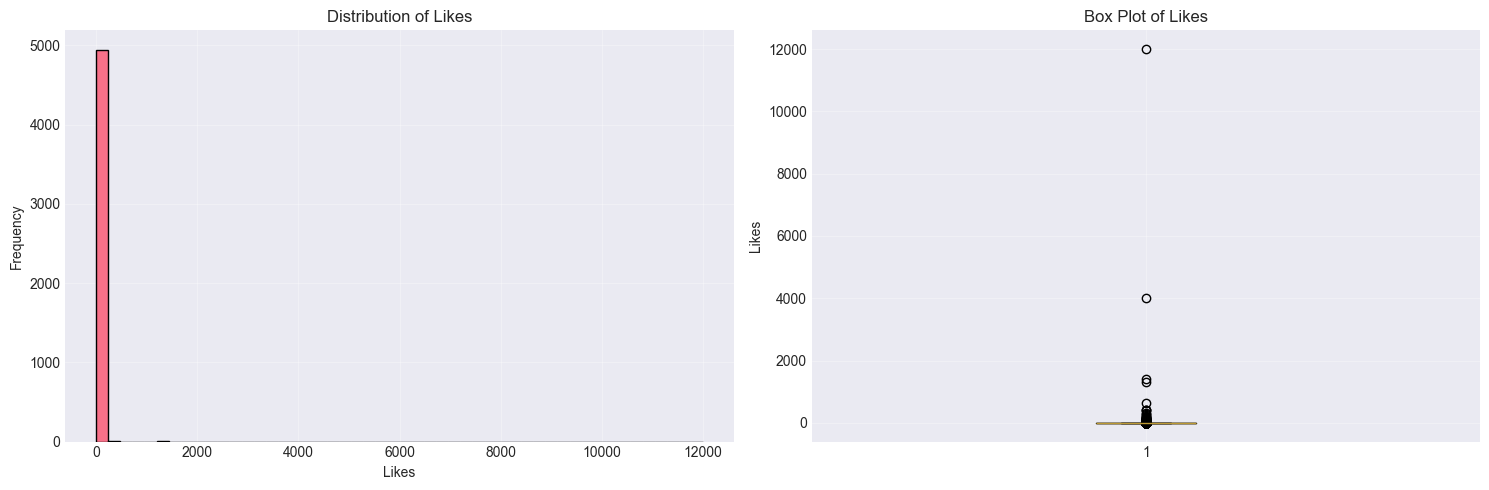

In [12]:
# Likes distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df_clean['likes'], bins=50, edgecolor='black')
axes[0].set_xlabel('Likes')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Likes')
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(df_clean['likes'])
axes[1].set_ylabel('Likes')
axes[1].set_title('Box Plot of Likes')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

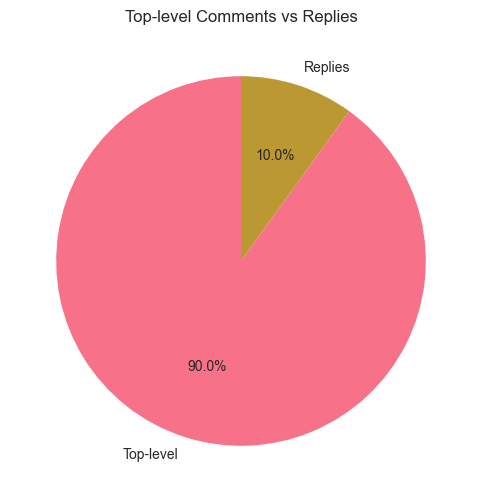

In [13]:
# Top-level comments vs Replies
reply_counts = df_clean['is_reply'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(reply_counts.values, labels=['Top-level', 'Replies'], autopct='%1.1f%%', startangle=90)
plt.title('Top-level Comments vs Replies')
plt.show()

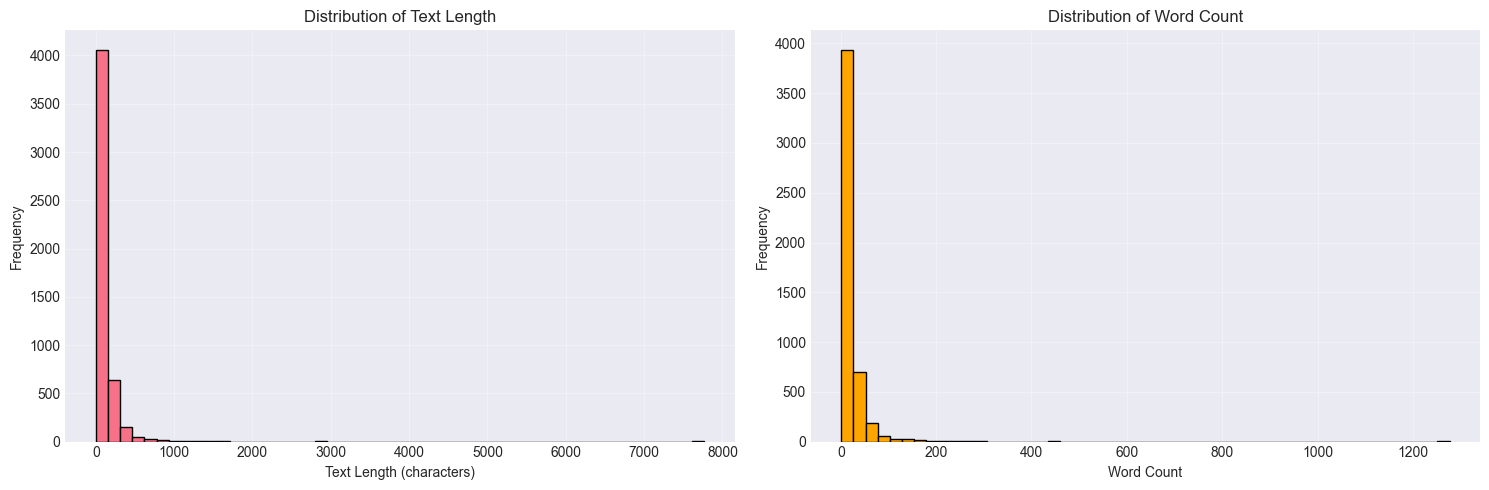

In [14]:
# Text length distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df_clean['text_length'], bins=50, edgecolor='black')
axes[0].set_xlabel('Text Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Text Length')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df_clean['word_count'], bins=50, edgecolor='black', color='orange')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Word Count')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

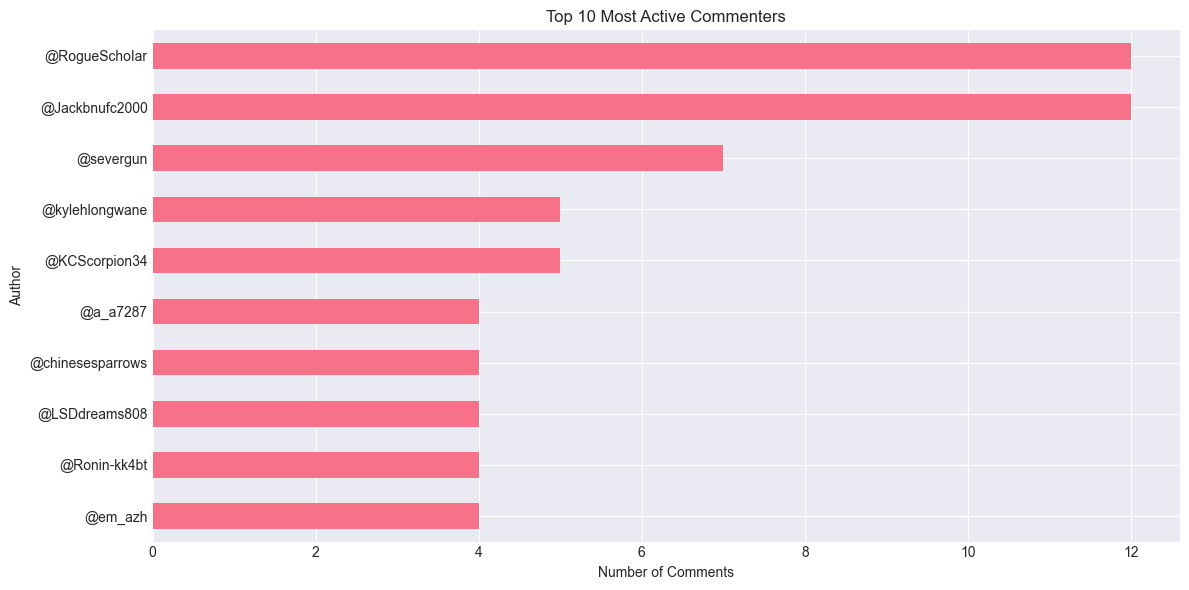

In [15]:
# Top authors by comment count
top_authors = df_clean['author'].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_authors.plot(kind='barh')
plt.xlabel('Number of Comments')
plt.ylabel('Author')
plt.title('Top 10 Most Active Commenters')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [16]:
# Top liked comments
top_liked = df_clean.nlargest(10, 'likes')[['author', 'text', 'likes']]
print("Top 10 Most Liked Comments:")
print("=" * 100)
for idx, row in top_liked.iterrows():
    print(f"\nAuthor: {row['author']}")
    print(f"Likes: {row['likes']}")
    print(f"Comment: {row['text'][:200]}..." if len(row['text']) > 200 else f"Comment: {row['text']}")
    print("-" * 100)

Top 10 Most Liked Comments:

Author: @em_azh
Likes: 12000
Comment: 4:09 i can finally hide my single-digit bank balance
----------------------------------------------------------------------------------------------------

Author: @angelaferkel7922
Likes: 4000
Comment: So it went from titanium to aluminium and the price went up?
----------------------------------------------------------------------------------------------------

Author: @Violakristii
Likes: 1400
Comment: The privacy screen is quite impressive, particularly in certain places such as alerts or passcodes.
----------------------------------------------------------------------------------------------------

Author: @Meshach_Stephen
Likes: 1300
Comment: Wait.. so he wasn't chilling in the clouds?
----------------------------------------------------------------------------------------------------

Author: @Stark720s
Likes: 628
Comment: That's the cost of RAM, driving up the price. 🤣
--------------------------------------------

## 8. Save Preprocessed Data

In [17]:
# Save cleaned data
output_file = '../samsungs26_preprocessed.csv'
df_clean.to_csv(output_file, index=False, encoding='utf-8-sig')
print(f"Preprocessed data saved to: {output_file}")
print(f"Final shape: {df_clean.shape}")

Preprocessed data saved to: ../samsungs26_preprocessed.csv
Final shape: (4953, 12)


## 9. Summary

In [18]:
print("=" * 70)
print("PREPROCESSING SUMMARY")
print("=" * 70)
print(f"Original dataset: {df.shape[0]} rows")
print(f"Cleaned dataset: {df_clean.shape[0]} rows")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")
print(f"Columns: {df_clean.shape[1]}")
print(f"\nNew columns added:")
print("  - text_length")
print("  - word_count")
print("  - text_cleaned")
print("=" * 70)

PREPROCESSING SUMMARY
Original dataset: 4953 rows
Cleaned dataset: 4953 rows
Rows removed: 0
Columns: 12

New columns added:
  - text_length
  - word_count
  - text_cleaned
